<a href="https://colab.research.google.com/github/Aqeedathussain/PakistaniDiabetesPredictor/blob/main/Diabetes_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Probability of a person being Diabetic Calculating Model:

In [9]:
# Importing Libraries and Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_excel('/content/Pakistani_Diabetes_Dataset.xlsx')
# Drop the duration column
df.drop('Duration', axis=1, inplace=True)
df.head()

,Age,Gender,Region,weight,BMI,wst,Systolic_Blood_Pressure,diastolic_Blood_Pressure,History,A1c,B.S.R,vision,Exercise,Polydipsia,Polyuria,nephropathy,High_Density_Lipoprotein,Outcome
0,60.0,1,0,76.0,29.90,41.0,130,90,0,8.90,278,0,30,1,0,0,60,1
1,57.0,1,1,64.0,24.30,39.0,120,80,1,8.50,165,0,20,1,1,0,42,1
2,58.0,0,0,73.0,25.20,34.0,140,90,0,5.65,130,1,20,0,0,0,54,0
3,27.0,0,1,60.0,22.01,30.0,110,70,0,5.00,95,0,15,0,0,0,57,0
4,56.0,1,0,70.0,25.80,43.0,125,90,0,8.30,139,1,40,1,0,1,53,1


Changing the datatypes of the columns(Which require)

In [10]:
# Changing the datatype of age and weight to int columns
df['Age']=df['Age'].astype(int)
df['weight']=df['weight'].astype(int)

Removing the outliers

In [11]:
# Selecting the columns with most outliers
numeric_col=['Age', 'B.S.R', 'Systolic_Blood_Pressure', 'diastolic_Blood_Pressure', 'BMI', 'weight', 'High_Density_Lipoprotein']

# Removing outliers with Inter Quartile Range
for col in numeric_col:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  df=df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]
df_copy=df.copy()

# Dividing data into features and labels
x=df_copy.iloc[:, :-1]
y=df_copy.iloc[:, -1]

splitting into training and test set


In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.25, random_state=0)


Scaling the columns with continuous values by Standard Scalar

In [13]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

# Scaling the columns with the continuous values
continuous_col=['Age', 'weight', 'BMI', 'wst', 'Systolic_Blood_Pressure', 'diastolic_Blood_Pressure', 'A1c', 'B.S.R', 'Exercise', 'High_Density_Lipoprotein']

x_train[continuous_col] = sc.fit_transform(x_train[continuous_col])
x_test[continuous_col] = sc.transform(x_test[continuous_col])

Trianing models


In [16]:
# Importing all libraries for model training and evaluation

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score
from sklearn.model_selection import GridSearchCV

# Selecting the model and their names
models=[LogisticRegression(class_weight='balanced'), KNeighborsClassifier(), SVC(class_weight='balanced'), RandomForestClassifier(class_weight='balanced')]
model_names_list=['Logistic_Regression', 'KNN', 'SVC', 'Random_Forest']

# Parameter Grids
param_grid={'Logistic_Regression':{
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'random_state': [0],
    'solver': ['liblinear']
},
            'KNN':{

                 'n_neighbors': [3 , 5 , 7 , 9],
                 'p':[2 , 3 , 4 , 5 , 6 , 7 , 8 , 9],
                 'weights':['uniform', 'distance']
            },
            'SVC':{
                'C':[0.001, 0.01, 0.1, 1, 10, 100],
                'kernel':['rbf', 'linear', 'poly', 'sigmoid']

            },
            'Random_Forest':
            {
             'random_state': [0],
             'n_estimators':[10 , 50 , 100 , 200],
             'max_depth':[None, 5 , 10 , 15]

            }
            }


# Initializing lists to store metrics for plotting
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

# Training and tuning
model_result=[]

best_score=0

best_model=None

# Tunning the models one by one
for model, current_model_name in zip(models, model_names_list):
  print('Tuning the model', current_model_name)

  # Tuning using GridSearchCV
  grid_search=GridSearchCV(estimator=model, param_grid=param_grid[current_model_name],
                           scoring= 'f1',
                           cv=5,
                           n_jobs=-1,
                           refit=True
                           )
  # Training model
  grid_search.fit(x_train, y_train)

  # Extracting the best parameters
  best_params=grid_search.best_params_
  print('Best parameters for the model', current_model_name, 'are', best_params, '\n')

  # Evaluate the current best estimator and store metrics
  current_model_best_estimator = grid_search.best_estimator_
  y_test_pred_current = current_model_best_estimator.predict(x_test)

  accuracy_list.append(accuracy_score(y_test, y_test_pred_current))
  precision_list.append(precision_score(y_test, y_test_pred_current))
  f1_list.append(f1_score(y_test, y_test_pred_current))
  recall_list.append(recall_score(y_test, y_test_pred_current))

  # Selecting the best tunned model (overall best based on f1 score from GridSearchCV)
  if grid_search.best_score_>best_score:
    best_score=grid_search.best_score_
    best_model=current_model_best_estimator

# Printing the best model name
print('The best tunned model is', best_model, '\n')

# Selecting the columns where the user input is needed
user_col=['Age', 'Gender', 'Region', 'weight', 'BMI', 'wst',
       'Systolic_Blood_Pressure', 'diastolic_Blood_Pressure', 'History', 'A1c',
       'B.S.R', 'vision', 'Exercise', 'Polydipsia', 'Polyuria',
       'nephropathy', 'High_Density_Lipoprotein']


#Getting the user input one by one
age=int(input('Enter your age\n'))
gender=int(input('Enter your Gender(1 for male and 0 for female) \n'))
region=int(input('Enter your region(0 for Rural and 1 for urban)\n'))
weight=int(input('Enter your weight(in kg)\n'))
bmi=float(input('Enter your Body Mass Index\n'))
wst=float(input('Enter your waist circumference(in cm)\n'))
systolic=int(input('Enter your Systolic_blood_Pressure\n'))
diastolic=int(input('Enter your Diastolic_blood_Pressure\n'))
history=int(input('Enter your Family Diabetes history(0 if no history 1 if have history )\n'))
A1c=float(input('Enter your HbA1c test score in %\n'))
BSR=int(input('Enter your Blood Sugar Random in mg/dl\n'))
vision=int(input('Enter the condition of your vision( 1 if good 0 if not good)\n'))
exercise=int(input('Enter the minutes of exercise in day\n'))
polydypsia=int(input('Enter the condition of polydypsia(1 for Yes and 0 for No)\n'))
polyuria=int(input('Enter the condition of polyuria( 1 for Yes and 0 for No)\n'))
nephro=int(input ('Enter the condition of nephropahy ( 1 for Yes and 0 for No)\n'))
lipoprotein=int(input('Enter the amount of Lipoprotein (in mg/dl)\n'))


  #  Making dataframe of the user inputs
user=pd.DataFrame([[age, gender, region, weight, bmi, wst, systolic, diastolic, history, A1c, BSR, vision,
                          exercise, polydypsia, polyuria, nephro, lipoprotein]],
                    columns=user_col
                    )

# Selecting the continuous values from the user input
continuous=['Age', 'weight', 'BMI', 'wst', 'Systolic_Blood_Pressure', 'diastolic_Blood_Pressure' , 'A1c' , 'B.S.R' , 'Exercise' , 'High_Density_Lipoprotein']

# Scaling the inputs by user
scaled_values=sc.transform(user[continuous])
user_scaled=user.copy()
user_scaled[continuous]=scaled_values

# Making prediction
y_pred=best_model.predict(user_scaled)

# Output printing result
if y_pred[0]==0:
    print('The person is Healthy\n')
else:
    print('The person is diabetic\n')

# Predicting the percentage
if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(user_scaled)
    diabetes_prob = y_prob[0][1] * 100
    print("Probability of this person being diabetic is:", diabetes_prob, '\n')
else:
    print("Probability prediction not available for this model.\n")


  # Evaluating the models
y_test_pred=best_model.predict(x_test)

print('The accuracy_score of the ', best_model, 'is', accuracy_score(y_test, y_test_pred), '\n')

print('Precision Score of the', best_model, 'is' , precision_score(y_test, y_test_pred), '\n')

print('The f1 score of the ', best_model, 'is', f1_score(y_test, y_test_pred), '\n')

print('The recall score of the', best_model, 'is' , recall_score(y_test, y_test_pred), '\n')

Tuning the model Logistic_Regression
Best parameters for the model Logistic_Regression are {'C': 1, 'penalty': 'l1', 'random_state': 0, 'solver': 'liblinear'} 

Tuning the model KNN
Best parameters for the model KNN are {'n_neighbors': 5, 'p': 2, 'weights': 'distance'} 

Tuning the model SVC
Best parameters for the model SVC are {'C': 1, 'kernel': 'rbf'} 

Tuning the model Random_Forest
Best parameters for the model Random_Forest are {'max_depth': 5, 'n_estimators': 100, 'random_state': 0} 

The best tunned model is RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=0) 

Enter your age
45
Enter your Gender(1 for male and 0 for female) 
1
Enter your region(0 for Rural and 1 for urban)
0
Enter your weight(in kg)
56
Enter your Body Mass Index
30.5
Enter your waist circumference(in cm)
40
Enter your Systolic_blood_Pressure
140
Enter your Diastolic_blood_Pressure
90
Enter your Family Diabetes history(0 if no history 1 if have history )
0
Enter your HbA1c test score in

Plotting the models

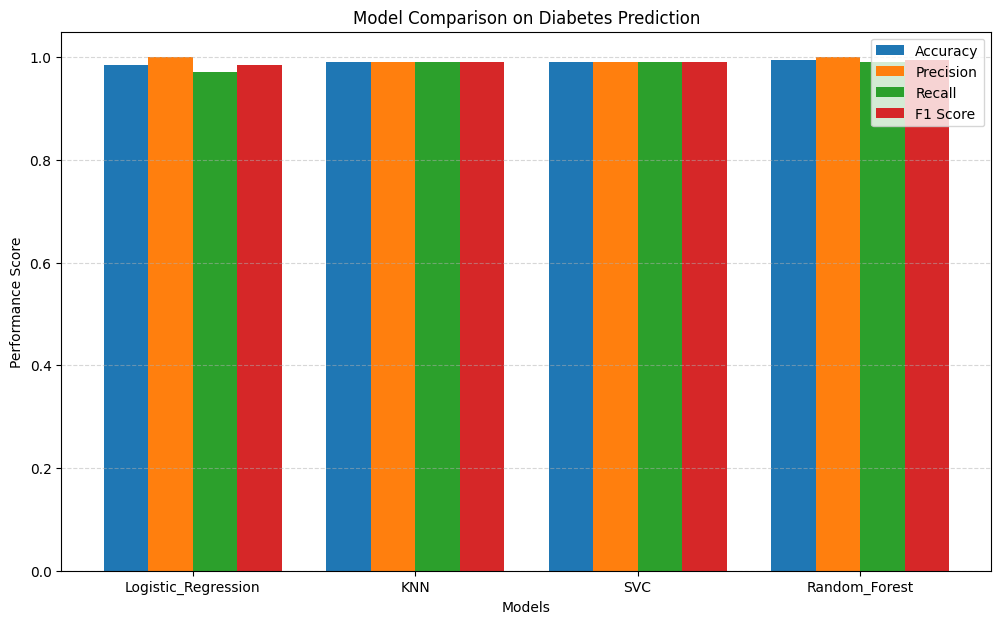

In [17]:

# Plotting the metrics

x = np.arange(len(model_names_list))
width = 0.2

plt.figure(figsize=(12, 7))

plt.bar(x - 0.3, accuracy_list, width, label='Accuracy')
plt.bar(x - 0.1, precision_list, width, label='Precision')
plt.bar(x + 0.1, recall_list, width, label='Recall')
plt.bar(x + 0.3, f1_list, width, label='F1 Score')

plt.xticks(x, model_names_list)
plt.xlabel("Models")
plt.ylabel("Performance Score")
plt.title("Model Comparison on Diabetes Prediction")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()
